# Model Comparison — Pneumonia X-Ray

## Background

The previous two notebooks each trained a different kind of model on the same problem —
classifying a chest X-ray as `NORMAL` or `PNEUMONIA` — but they never saw each other's numbers
side by side. `03_ml_modeling.ipynb` produced two classical-ML models fit on hand-engineered
pixel/texture/edge/region features (a Logistic Regression baseline, "M4", and an XGBoost
primary model, "M6"), selected via cross-validation. `04_dl_cv_transfer_learning.ipynb`
produced a ResNet18 fine-tuned directly on raw pixels via transfer learning. Both notebooks
evaluated their model(s) once on the exact same held-out `test` split and saved their raw
predictions (`y_true`, `y_pred_proba`) to `../artifacts/predictions/` — nothing more.

This notebook is the bridge between that training methodology and the deployed service: it
loads those two prediction files, recomputes an identical metric suite for all three models
from the same saved probabilities, and uses the result to decide — objectively, on a single
number (ROC-AUC) computed the same way for every model — which one gets promoted to
`ml-service/app/model/artifacts/model.onnx` and actually serves predictions in the running
application. It does not train, tune, or refit anything; it only reads what the other two
notebooks already computed.

### Loading the saved test-set predictions

`03_ml_modeling.ipynb` and `04_dl_cv_transfer_learning.ipynb` each ran their final model(s)
once over the identical `test` split and wrote the raw `y_true`/`y_pred_proba` columns to CSV,
rather than just printing a metrics summary. Loading those two files here — instead of
trusting each notebook's own printed numbers — is what lets every metric below be recomputed
by the exact same code for all three models, so the comparison is apples-to-apples.

In [1]:
import pandas as pd
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

phase3_df = pd.read_csv("../artifacts/predictions/phase3_test_predictions.csv")
phase4_df = pd.read_csv("../artifacts/predictions/phase4_test_predictions.csv")

print("phase3_test_predictions.csv (M4, M6):", phase3_df.shape)
print("phase4_test_predictions.csv (ResNet18):", phase4_df.shape)

phase3_df.head()

phase3_test_predictions.csv (M4, M6): (624, 4)
phase4_test_predictions.csv (ResNet18): (624, 3)


,Image_ID,y_true,y_pred_proba_m4,y_pred_proba_m6
0,IM-0001-0001.jpeg,0,0.295824,0.207494
1,IM-0003-0001.jpeg,0,0.636113,0.433845
2,IM-0005-0001.jpeg,0,0.282194,0.054036
3,IM-0006-0001.jpeg,0,0.992993,0.943789
4,IM-0007-0001.jpeg,0,0.283503,0.249803


### Recomputing an identical metric suite for all three models

To compare M4, M6, and ResNet18 fairly, every model's saved probabilities are reduced to the
same metrics using the same procedure: the threshold-dependent metrics
(Accuracy/Precision/Recall/F1) use a 0.5 probability cutoff, matching the threshold already
used when each source notebook evaluated its own model on `test`; ROC-AUC is computed directly
on the raw probabilities, since it is threshold-independent by construction. The confusion
matrix for each model is printed here too, as the most detailed view of each model's error
pattern before it gets collapsed into the single-row summary in the next step.

In [2]:
def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred_proba),
        "Confusion Matrix": confusion_matrix(y_true, y_pred),
    }


metrics_m4 = compute_metrics(phase3_df["y_true"], phase3_df["y_pred_proba_m4"])
metrics_m6 = compute_metrics(phase3_df["y_true"], phase3_df["y_pred_proba_m6"])
metrics_resnet18 = compute_metrics(phase4_df["y_true"], phase4_df["y_pred_proba_resnet18"])

for name, metrics in [
    ("M4 (Logistic Regression)", metrics_m4),
    ("M6 (XGBoost)", metrics_m6),
    ("ResNet18 (Transfer Learning)", metrics_resnet18),
]:
    print(f"{name} — confusion matrix (rows=true, cols=pred, order=[NORMAL, PNEUMONIA]):")
    print(metrics["Confusion Matrix"])
    print()

M4 (Logistic Regression) — confusion matrix (rows=true, cols=pred, order=[NORMAL, PNEUMONIA]):
[[135  99]
 [ 65 325]]

M6 (XGBoost) — confusion matrix (rows=true, cols=pred, order=[NORMAL, PNEUMONIA]):
[[127 107]
 [ 54 336]]

ResNet18 (Transfer Learning) — confusion matrix (rows=true, cols=pred, order=[NORMAL, PNEUMONIA]):
[[129 105]
 [  1 389]]



### Comparison table

The confusion matrices above are the full picture, but a decision needs a table that puts all
three models' scalar metrics side by side. This is the artifact that the promotion decision
below is actually based on.

In [3]:
scalar_keys = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison_df = pd.DataFrame(
    [
        {"Model": "M4 (Logistic Regression)", **{k: metrics_m4[k] for k in scalar_keys}},
        {"Model": "M6 (XGBoost)", **{k: metrics_m6[k] for k in scalar_keys}},
        {"Model": "ResNet18 (Transfer Learning)", **{k: metrics_resnet18[k] for k in scalar_keys}},
    ]
).set_index("Model")

comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
M4 (Logistic Regression),0.737179,0.766509,0.833333,0.798526,0.767905
M6 (XGBoost),0.741987,0.758465,0.861538,0.806723,0.803978
ResNet18 (Transfer Learning),0.830128,0.787449,0.997436,0.880090,0.942154


### ROC curve comparison

Accuracy/Precision/Recall/F1 all depend on the fixed 0.5 threshold chosen above, which can
hide how a model trades recall against precision at other thresholds. Overlaying the three
ROC curves shows that trade-off across every threshold at once, and visually confirms (or
challenges) whatever the ROC-AUC column in the comparison table above already says numerically
— if one curve clearly dominates the other two everywhere, that is strong visual evidence for
the numeric winner.

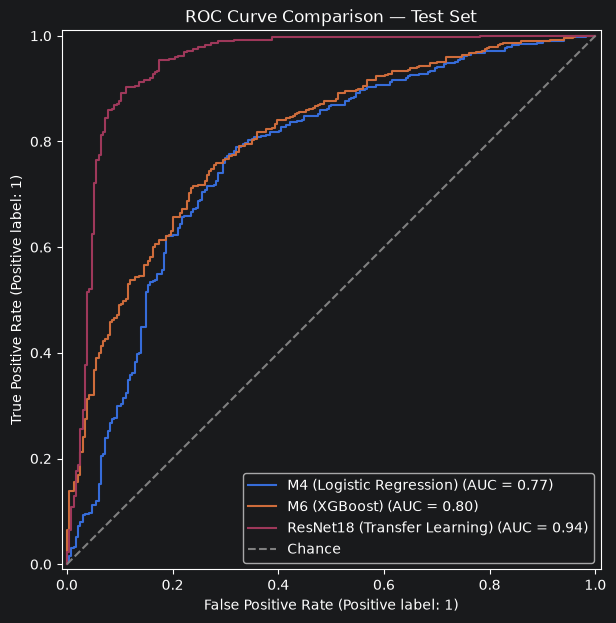

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

RocCurveDisplay.from_predictions(
    phase3_df["y_true"], phase3_df["y_pred_proba_m4"], name="M4 (Logistic Regression)", ax=ax
)
RocCurveDisplay.from_predictions(
    phase3_df["y_true"], phase3_df["y_pred_proba_m6"], name="M6 (XGBoost)", ax=ax
)
RocCurveDisplay.from_predictions(
    phase4_df["y_true"],
    phase4_df["y_pred_proba_resnet18"],
    name="ResNet18 (Transfer Learning)",
    ax=ax,
)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve Comparison — Test Set")
ax.legend(loc="lower right")
plt.show()

### Decision: selecting the model to promote

Whichever model scores highest on ROC-AUC over the shared `test` set is the one that should be
served by the running application. This cell states that winner and its key metrics
(ROC-AUC, Recall, Precision) — it does not generate promotion commands; the actual steps
(copying the winning model's ONNX export into `app/model/artifacts/` and updating
`app/model/manifest.yaml`) are documented in `lab/README.md`'s "Promoting a model" section.

In [7]:
winner = comparison_df["ROC-AUC"].idxmax()

print(f"Winner (highest ROC-AUC on test): {winner}")
print()
print(comparison_df.loc[[winner]])
print()

print(
    """metrics:
    auc:       {auc:.4f}
    recall:    {recall:.4f}
    precision: {precision:.4f}
""".format(
        auc=comparison_df.loc[winner, "ROC-AUC"],
        recall=comparison_df.loc[winner, "Recall"],
        precision=comparison_df.loc[winner, "Precision"],
    )
)

Winner (highest ROC-AUC on test): ResNet18 (Transfer Learning)

                              Accuracy  Precision    Recall       F1   ROC-AUC
Model                                                                         
ResNet18 (Transfer Learning)  0.830128   0.787449  0.997436  0.88009  0.942154

metrics:
    auc:       0.9422
    recall:    0.9974
    precision: 0.7874



### Conclusion

This notebook never trains or fits anything — it only reads the two prediction files written
by `03_ml_modeling.ipynb` (M4 and M6) and `04_dl_cv_transfer_learning.ipynb` (ResNet18),
recomputes an identical metric suite for all three on the exact same 624-image `test` split,
and lets ROC-AUC on that shared held-out set decide which model is served.

**Winner: ResNet18 (Transfer Learning)**, with ROC-AUC 0.9422 against M6's 0.8040 and M4's
0.7679 (comparison table above) — a decisive margin, not a close call that would need a second
look at the confusion matrices. Recall (0.9974) and Precision (0.7874) for the winning model
are read directly off the decision cell above. M4 and M6 serve here as classical-ML baselines
that quantify how much transfer learning on raw pixels gains over hand-engineered features,
rather than as deployment candidates in their own right; ResNet18's existing ONNX export
(`train.py`'s output in `04_dl_cv_transfer_learning.ipynb`) is what gets promoted, following
`lab/README.md`'s "Promoting a model" section.